## Processing the data

In [1]:
# !wget https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/refs/heads/master/ann_logistic_extra/ecommerce_data.csv

In [2]:
# Load the data
import numpy as np
import pandas as pd


def load_data():
    data = pd.read_csv('ecommerce_data.csv')
    return data

df = load_data()
df

,is_mobile,n_products_viewed,visit_duration,is_returning_visitor,time_of_day,user_action
0,1,0,0.657510,0,3,0
1,1,1,0.568571,0,2,1
2,1,0,0.042246,1,1,0
3,1,1,1.659793,1,1,2
4,0,1,2.014745,1,1,2
...,...,...,...,...,...,...
495,1,3,0.731594,0,0,2
496,0,0,6.368775,1,3,0
497,0,0,0.172853,1,3,0
498,1,0,0.209964,0,3,0


<Axes: >

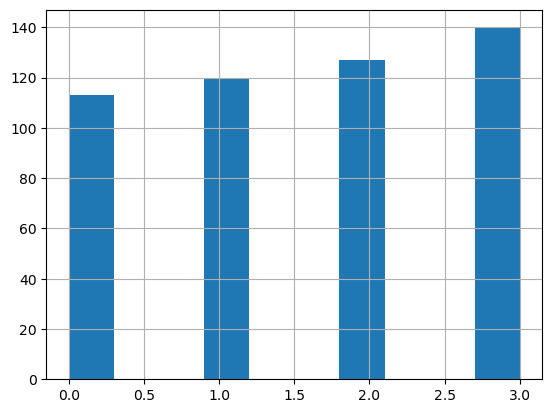

In [3]:
df.['time_of_day'].hist()

In [4]:
def get_data():
    df = pd.read_csv('ecommerce_data.csv')

    # Convert to NumPy arrays
    data = df.to_numpy()

    # Shuffle the data
    np.random.shuffle(data)

    # Split into input (X) and output (y)
    X = data[:, :-1]
    y = data[:, -1].astype(np.int32)

    N, D = X.shape
    X2 = np.zeros((N, D + 3))  # Add a column of ones for bias
    X2[:, :(D-1)] = X[:, :(D-1)] # Non-categorical columns

    # One-hot encode the categorical data
    # Method 1
    # for n in range(N):
    #     t = int(X[n, D-1])
    #     X2[n, t+D-1] = 1

    # Method 2 - More efficient
    Z = np.zeros((N, 4))
    Z[np.arange(N), X[:, D-1].astype(np.int32)] = 1
    X2[:,-4:] = Z
    X = X2

    # Split train and test data
    Xtrain = X[:-100]
    Ytrain = y[:-100]
    Xtest = X[-100:]
    Ytest = y[-100:]

    # Standardize the data - columns 1 and 2
    for i in (1, 2):
        mean_ = Xtrain[:,i].mean()
        std_ = Xtrain[:,i].std()
        Xtrain[:,i] = (Xtrain[:,i] - mean_) / std_
        Xtest[:,i] = (Xtest[:,i] - mean_) / std_

    return Xtrain, Ytrain, Xtest, Ytest


In [5]:
Xtrain, Ytrain, _, _ = get_data()

In [6]:
Xtrain.shape, Ytrain.shape

((400, 8), (400,))

In [7]:
# Convert to binary format
def get_binary_data():
    # return only the data from the first 2 classes
    Xtrain, Ytrain, Xtest, Ytest = get_data()
    X2train = Xtrain[Ytrain <= 1]
    Y2train = Ytrain[Ytrain <= 1]
    X2test = Xtest[Ytest <= 1]
    Y2test = Ytest[Ytest <= 1]
    return X2train, Y2train, X2test, Y2test

In [8]:
get_binary_data()

(array([[ 1.        ,  0.13604206, -0.30356201, ...,  0.        ,
          0.        ,  1.        ],
        [ 1.        , -0.81863907,  0.60416646, ...,  0.        ,
          1.        ,  0.        ],
        [ 1.        ,  0.13604206, -0.69014008, ...,  0.        ,
          0.        ,  1.        ],
        ...,
        [ 0.        ,  1.09072319, -0.68052291, ...,  1.        ,
          0.        ,  0.        ],
        [ 0.        , -0.81863907,  0.64938321, ...,  1.        ,
          0.        ,  0.        ],
        [ 0.        , -0.81863907, -0.76682867, ...,  0.        ,
          0.        ,  0.        ]]),
 array([1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
        0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
        0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
        1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
   

In [9]:
Ytrain <= 1

array([ True, False, False, False,  True, False,  True, False, False,
        True, False,  True,  True, False, False,  True, False, False,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True, False,  True,  True,  True,  True,  True, False,  True,
        True, False,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True, False,
        True,  True, False,  True,  True, False, False,  True, False,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

## Make predictions

In [10]:
# Define softmax function
def softmax(a):
        expA = np.exp(a)
        A = expA / expA.sum(axis=1, keepdims=True) # A - activation function
        return A
    
 # Define forward pass function
def forward_pass(X, W1, b1, W2, b2):
    Z = np.tanh(X.dot(W1) + b1)
    return softmax(Z.dot(W2) + b2)

In [11]:
def predict(X, Y):
    # Randomly initialized weights
    M = 5
    D = X.shape[1]
    K = len(set(Y))

    # Initialize weights and biases
    W1 = np.random.randn(D, M)
    b1 = np.random.randn(M)

    W2 = np.random.randn(M, K)
    b2 = np.random.randn(K)

    # Forward pass
    P_Y_given_X = forward_pass(X, W1, b1, W2, b2)

    # Get predictions
    predictions = np.argmax(P_Y_given_X, axis=1)

    # Calculate accuracy
    accuracy = np.mean(predictions == Y)

    return P_Y_given_X, predictions, round(accuracy, 4)

In [12]:
probabilities, predictions, accuracy = predict(Xtrain, Ytrain)

In [13]:
probabilities.shape

(400, 4)

In [14]:
probabilities

array([[0.24177295, 0.64698982, 0.01834595, 0.09289128],
       [0.20220371, 0.65381585, 0.00998504, 0.1339954 ],
       [0.17055891, 0.0804668 , 0.00135221, 0.74762208],
       ...,
       [0.26787886, 0.65111434, 0.04141564, 0.03959116],
       [0.05809423, 0.81382055, 0.10165267, 0.02643256],
       [0.16647886, 0.56880055, 0.18777047, 0.07695012]])

In [15]:
predictions

array([1, 1, 3, 1, 1, 1, 1, 3, 1, 0, 1, 0, 1, 3, 1, 1, 1, 1, 0, 1, 1, 3,
       0, 0, 0, 3, 3, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 3, 1, 1, 3, 1, 1, 3,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 3, 0, 0, 1, 1, 3, 1, 1, 1, 3, 0, 1, 1,
       1, 1, 1, 3, 1, 3, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       3, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 2, 0, 1, 3, 1, 1, 1, 0, 0,
       3, 0, 3, 1, 1, 3, 3, 1, 0, 3, 2, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       3, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 3, 0, 1, 1, 3, 1, 0, 0, 1, 1, 1, 0, 3, 1, 1,
       1, 1, 3, 0, 1, 2, 1, 1, 1, 0, 0, 1, 1, 1, 1, 3, 3, 1, 3, 3, 1, 2,
       1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 3, 1, 0, 1, 0, 1, 0, 1, 3, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 3, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 3, 3, 3, 1,
       0, 3, 1, 3, 3, 0, 0, 2, 1, 1, 1, 1, 3, 0, 1, 0, 3, 1, 1, 1, 3, 3,
       1, 1, 0, 1, 1, 0, 3, 1, 0, 1, 1, 1, 2, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 2, 1, 1, 0, 1, 1, 0, 3, 1, 1, 0, 1, 1, 0,

In [16]:
accuracy

np.float64(0.4825)

## Classification rate

In [22]:
# Classification rate
def classification_rate(Y, P): # P is the predicted probabilities, Y is the true labels (targets)
    return np.mean(Y == np.argmax(P, axis=1)) * 100

In [23]:
classification_rate(Ytrain, probabilities)

np.float64(48.25)